# Final Project: Spark ALS + Tag Genome Hybrid on MovieLens 32M

This notebook trains a Spark ALS recommender on MovieLens 32M and reranks its predictions with MovieLens Tag Genome features.

**How to run**

- `RUN_DOWNLOAD` — download MovieLens 32M + Tag Genome if missing, convert to parquet, remove converted CSVs
- `RUN_ALS` — Spark ALS on full ratings
- `RUN_GENOME` — Tag Genome hybrid rerank

Defaults are off so **Run All** is safe when `data/` and `data/results/` already exist. Flip a flag to True to run that stage.

**Hardware note:** Tuned for Windows with ~31 GB RAM and Spark `local[2–4]` (this notebook uses `local[4]`, driver heap 6g, spill-friendly cache). A full ALS + hybrid pass is resource-heavy; close other apps and keep the memory policy in the ALS cell. Without it, full-data runs can freeze the machine.

**Data on disk:** After download, the working tables are **parquet** under `data/` (`ratings.parquet`, `movies.parquet`, `glmer.parquet`, …). CSVs may exist only before conversion.


---

## 1. Data

Both datasets come from [MovieLens / GroupLens](https://grouplens.org/datasets/movielens/).

| Source | Link | Use |
|--------|------|-----|
| **MovieLens 32M** | [ml-32m.zip](https://files.grouplens.org/datasets/movielens/ml-32m.zip) | Ratings, movie titles, genres, and external IDs |
| **Tag Genome 2021** | [genome_2021.zip](https://files.grouplens.org/datasets/tag-genome-2021/genome_2021.zip) | Tag relevance scores used as content features |

MovieLens provides the user–movie ratings used by ALS. Tag Genome represents each movie as a vector of tag relevance scores.

Local file layout:

```text
data/
  ratings.csv
  movies.csv
  links.csv
  glmer.csv
  results/
```

The main flow of the download stage converts the CSV files to parquet and removes the converted CSV copies.


---

## 2. Design notes

The possible user–movie matrix is huge (~200k users × ~84k movies ≈ 17 billion cells), but only ~32 million ratings are observed (~0.19% dense). ALS never materializes the dense matrix: it works with observed pairs and learns low-rank user and movie factors (here rank 10).

**Tuning strategy (why the knobs look the way they do):** hyperparameter search on a small user sample is cheaper than refitting full 32M many times. The notebook hard-codes the chosen ALS settings; the **story and numbers from that search** are written up **after** the ALS/hybrid code and outputs, so results are not spoiled before you see how they are produced.

**Hybrid idea:** after ALS, each movie can also be a Tag Genome vector. A user profile is the mean tag vector of training movies they liked (≥ 4.0). Candidates are re-scored by blending scaled ALS with cosine similarity when both sides have signal.

**Memory:** full-data local Spark needs spill-friendly cache, unpersist, and heap caps—details in Part 1.

### Pipeline overview

```text
MovieLens data
|──► ratings data ──► Spark ALS ──► train_ratings.parquet
|                        └──► simpler_predictions.parquet
|                                          │
└──► Tag Genome ──► hybrid reranking ◄─────┘
                         └──► hybrid_predictions.parquet
```

| Stage | Process |
|-------|---------|
| **ALS** | Load ratings, create an 80/20 split, train Spark ALS, calculate test RMSE, and save the training rows and test predictions. |
| **Hybrid** | Build a movie-by-tag matrix, create user profiles from training ratings of at least 4.0, and blend ALS with cosine similarity when both signals are available. |

Selected settings:

| | |
|--|--|
| ALS | `rank=10`, `maxIter=10`, `regParam=0.05`, seed 50 |
| Hybrid | ALS weight 0.70, like threshold 4.0, minimum 3 liked genome movies |

`hybrid_score` is used for ranking rather than as a predicted star rating. Rows without a usable genome signal keep the scaled ALS score.

The ALS hyperparameters were selected via a gridsearch that was done locally during testing. More information about it later on.

---

---

## 3. Code

Executable stages in this notebook:

0. **Data setup** — flags/paths and optional download → parquet (Part 0 under Data above)
1. **Spark ALS** — fit, evaluate, write train split + predictions
2. **Tag Genome hybrid** — rerank saved predictions

Flags: `RUN_DOWNLOAD`, `RUN_ALS`, `RUN_GENOME` (near the top). Defaults off reuse `data/results/` when present.


### i. Data Setup

The code below sets up the flags, paths, and libraries used for the program.

In [ ]:
from __future__ import annotations

import json
import os
import shutil
import sys
import tempfile
import urllib.request
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Set a flag to True to run that stage.
RUN_DOWNLOAD = False  # Download data and convert it to parquet
RUN_ALS = False       # Train Spark ALS
RUN_GENOME = False    # Run hybrid reranking

ROOT = Path(".").resolve()
DATA = ROOT / "data"
RESULTS = DATA / "results"

print("ROOT:", ROOT)
print("RUN_DOWNLOAD=", RUN_DOWNLOAD, " RUN_ALS=", RUN_ALS, " RUN_GENOME=", RUN_GENOME)


ROOT: C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project
RUN_DOWNLOAD= False  RUN_ALS= True  RUN_GENOME= True


In [2]:
# Download missing data, convert CSV files to parquet, and remove converted CSVs.

ML_URL = "https://files.grouplens.org/datasets/movielens/ml-32m.zip"
GENOME_URL = "https://files.grouplens.org/datasets/tag-genome-2021/genome_2021.zip"

TO_PARQUET = (
    ("ratings.csv", "ratings.parquet"),
    ("movies.csv", "movies.parquet"),
    ("links.csv", "links.parquet"),
    ("glmer.csv", "glmer.parquet"),
)


def _csv_to_parquet(csv_name: str, parquet_name: str, force: bool = False) -> bool:
    """Convert a CSV file to parquet if needed."""
    csv_path = DATA / csv_name
    pq_path = DATA / parquet_name
    if pq_path.exists() and not force:
        print(f"  parquet ok: {parquet_name}")
        return True
    if not csv_path.exists():
        print(f"  skip {parquet_name} (no {csv_name})")
        return pq_path.exists()
    print(f"  converting {csv_name} -> {parquet_name} …")
    df = pd.read_csv(csv_path)
    df.to_parquet(pq_path, index=False)
    print(f"  wrote {pq_path.name} ({len(df):,} rows)")
    return True


def _cleanup_csv_after_parquet() -> None:
    """Remove CSV files that have parquet replacements."""
    for csv_name, pq_name in TO_PARQUET:
        csv_path = DATA / csv_name
        pq_path = DATA / pq_name
        if csv_path.exists() and pq_path.exists():
            csv_path.unlink()
            print(f"  removed {csv_name} (kept {pq_name})")


def ensure_data(force: bool = False) -> Path:
    DATA.mkdir(parents=True, exist_ok=True)
    (DATA / "results").mkdir(exist_ok=True)
    (DATA / "spark_tmp").mkdir(exist_ok=True)

    need_ml = force or not (
        all((DATA / f).exists() for f in ("ratings.parquet", "movies.parquet", "links.parquet"))
        or all((DATA / f).exists() for f in ("ratings.csv", "movies.csv", "links.csv"))
    )
    need_glmer = force or not (
        (DATA / "glmer.parquet").exists() or (DATA / "glmer.csv").exists()
    )

    if need_ml or need_glmer:
        tmp = Path(tempfile.mkdtemp(prefix="final_project_data_"))
        try:
            if need_ml:
                print("Downloading MovieLens 32M…")
                ml_zip = tmp / "ml-32m.zip"
                urllib.request.urlretrieve(ML_URL, ml_zip)
                with zipfile.ZipFile(ml_zip) as z:
                    for name in (
                        "ml-32m/ratings.csv",
                        "ml-32m/movies.csv",
                        "ml-32m/links.csv",
                        "ml-32m/tags.csv",
                        "ml-32m/README.txt",
                    ):
                        if name not in z.namelist():
                            continue
                        out = DATA / Path(name).name
                        print(" ", name, "->", out.name)
                        with z.open(name) as src, open(out, "wb") as dst:
                            shutil.copyfileobj(src, dst)

            if need_glmer:
                print("Downloading Tag Genome 2021 (~1.8 GB, keeping only glmer.csv)…")
                g_zip = tmp / "genome_2021.zip"
                urllib.request.urlretrieve(GENOME_URL, g_zip)
                with zipfile.ZipFile(g_zip) as z:
                    name = "scores/glmer.csv"
                    if name not in z.namelist():
                        hits = [n for n in z.namelist() if n.endswith("glmer.csv")]
                        if not hits:
                            raise FileNotFoundError("glmer.csv not in genome zip")
                        name = hits[0]
                    out = DATA / "glmer.csv"
                    print(" ", name, "->", out.name)
                    with z.open(name) as src, open(out, "wb") as dst:
                        shutil.copyfileobj(src, dst)
        finally:
            shutil.rmtree(tmp, ignore_errors=True)
            print("Temp cleaned up.")
    else:
        print("Source data already present under", DATA)

    print("Parquet caches:")
    for csv_name, pq_name in TO_PARQUET:
        _csv_to_parquet(csv_name, pq_name, force=force)

    print("CSV cleanup:")
    _cleanup_csv_after_parquet()

    print("Done. Data in", DATA)
    return DATA


# Create output folders.
DATA.mkdir(parents=True, exist_ok=True)
(DATA / "results").mkdir(exist_ok=True)
(DATA / "spark_tmp").mkdir(exist_ok=True)
RESULTS = DATA / "results"

if RUN_DOWNLOAD:
    ensure_data(force=False)
else:
    print("Skipped download/convert (RUN_DOWNLOAD=False). Expect files under data/.")

print("RESULTS:", RESULTS)


Skipped download/convert (RUN_DOWNLOAD=False). Expect files under data/.
RESULTS: C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results


The cell below downloads the zip files from Movielens, unzips the files needed, converts files from csv to parquet, then removes the csv files. 

In [3]:
# Use parquet when available.
movies_path = DATA / "movies.parquet"
if not movies_path.exists():
    movies_path = DATA / "movies.csv"

ratings_path = DATA / "ratings.parquet"
if not ratings_path.exists():
    ratings_path = DATA / "ratings.csv"

movies = (
    pd.read_parquet(movies_path)
    if movies_path.suffix == ".parquet"
    else pd.read_csv(movies_path)
)
ratings_head = (
    pd.read_parquet(ratings_path).head(5)
    if ratings_path.suffix == ".parquet"
    else pd.read_csv(ratings_path, nrows=5)
)

print(f"movies: {len(movies):,} rows  ({movies_path.name})")
print(f"ratings: full file is ~32M rows (showing first 5 only)  ({ratings_path.name})\n")

display(movies.head())
display(ratings_head)


movies: 87,585 rows  (movies.parquet)
ratings: full file is ~32M rows (showing first 5 only)  (ratings.parquet)



,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


### Data summary

The next cell counts **source** ratings only (from `data/ratings.parquet` or CSV). Train/test sizes and model metrics appear **after** the ALS/hybrid code, once those stages have written `data/results/`.


In [14]:
# Source data summary (ratings file only — no model spoilers)
from IPython.display import display

def _ratings_path() -> Path:
    p = DATA / "ratings.parquet"
    return p if p.exists() else DATA / "ratings.csv"

path = _ratings_path()
if not path.exists():
    raise FileNotFoundError(
        f"Missing ratings under {DATA}. Set RUN_DOWNLOAD=True and run the download cell."
    )

if path.suffix.lower() == ".parquet":
    ratings_df = pd.read_parquet(path, columns=["userId", "movieId", "rating"])
else:
    ratings_df = pd.read_csv(path, usecols=["userId", "movieId", "rating"])

ratings_df = ratings_df.dropna(subset=["userId", "movieId", "rating"])
ratings_df = ratings_df.drop_duplicates(["userId", "movieId"])

summary = pd.DataFrame(
    [
        {"metric": "Ratings source", "value": path.name},
        {"metric": "Ratings after dedupe", "value": f"{len(ratings_df):,}"},
        {"metric": "Users", "value": f"{int(ratings_df['userId'].nunique()):,}"},
        {"metric": "Rated movies", "value": f"{int(ratings_df['movieId'].nunique()):,}"},
        {
            "metric": "Rating scale (min–max)",
            "value": f"{float(ratings_df['rating'].min()):g} – {float(ratings_df['rating'].max()):g}",
        },
    ]
)
print("From local ratings file (re-run anytime to verify):")
display(summary)
del ratings_df


From local ratings file (re-run anytime to verify):


,metric,value
0,Ratings source,ratings.parquet
1,Ratings after dedupe,"32,000,204"
2,Users,"200,948"
3,Rated movies,"84,432"
4,Rating scale (min–max),0.5 – 5


Deduplication left all 32.0M ratings intact (no duplicate user–movie pairs), spanning ~201k users and ~84k movies.

### ii. Spark ALS

This stage builds and evaluates the main collaborative filtering model.

It starts a local Spark session, loads the ratings and movie data, cleans them, and creates a reproducible 80/20 train-test split. Large intermediate DataFrames are released when they are no longer needed to reduce memory pressure.

The training data is saved for the later hybrid stage. ALS is then fitted on the training set, evaluated with test RMSE, and the predictions and summary metrics are written to disk.

Because the dataset is large, Spark handles all full-size Parquet outputs. Pandas is only used to create the small 200-row CSV sample.

**Memory settings used:**

* 6 GB Spark driver memory
* 4 local worker threads
* 8 shuffle partitions
* Large DataFrames use `MEMORY_AND_DISK`, allowing Spark to spill to `data/spark_tmp`
* Progress messages are printed during major stages so slow steps are easier to identify

**Note:**
I ran into Windows-specific issues with Hadoop and `winutils` when using Spark to write Parquet files. To resolve this, I installed the Hadoop 3.3 binary utilities and added them to the system path.

Earlier versions of the notebook moved data through Pandas and CSV files. I revised the pipeline so that large datasets are now read and written directly through Spark, which better preserves the distributed workflow.

In my local tests, Spark’s Parquet output took noticeably longer than the earlier Pandas-based approach. I did not benchmark the two methods formally, so this should be treated as an anecdotal observation.

In [ ]:
# Spark settings

# Hadoop check: Spark on Windows needs HADOOP_HOME with bin\winutils.exe for local parquet writes.
_hadoop_home = Path(os.environ.get("HADOOP_HOME") or (Path.home() / "hadoop"))
_winutils = _hadoop_home / "bin" / "winutils.exe"
if _winutils.exists():
    os.environ["HADOOP_HOME"] = str(_hadoop_home)
    _bin = str(_hadoop_home / "bin")
    if _bin not in os.environ.get("PATH", ""):
        os.environ["PATH"] = _bin + os.pathsep + os.environ.get("PATH", "")
    print(f"HADOOP_HOME={os.environ['HADOOP_HOME']}  winutils=OK")
else:
    print(
        f"WARNING: winutils not found at {_winutils}. "
        "Spark write.parquet on Windows may fail. "
        r"Expected layout: %USERPROFILE%\hadoop\bin\winutils.exe"
    )

os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
# Local Spark resource caps for ~30GB Windows machine
os.environ["PYSPARK_SUBMIT_ARGS"] = (
    "--master local[4] --driver-memory 6g "
    "--conf spark.driver.maxResultSize=1g "
    "pyspark-shell"
)

from pyspark import StorageLevel
# RMSE evaluator
from pyspark.ml.evaluation import RegressionEvaluator
# ALS model
from pyspark.ml.recommendation import ALS
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import (
    FloatType,
    IntegerType,
    LongType,
    StringType,
    StructField,
    StructType,
)

RESULTS_JSON = RESULTS / "simpler_als_results.json"
PREDS_PARQUET = RESULTS / "simpler_predictions.parquet"
PREDS_SAMPLE = RESULTS / "simpler_predictions_sample.csv"
TRAIN_RATINGS_PARQUET = RESULTS / "train_ratings.parquet"

RANK, MAX_ITER, REG = 10, 10, 0.05
SEED, TRAIN_FRAC, SAMPLE_N = 50, 0.80, 200

# Memory knobs derived from test iterations not included.
SPARK_SHUFFLE_PARTITIONS = 8
SPARK_PARALLELISM = 8
SPARK_MEMORY_FRACTION = 0.5
SPARK_STORAGE_FRACTION = 0.2
SPARK_MAX_RESULT_SIZE = "1g"
# Spill-friendly cache (prefer disk over heap growth under pressure)
CACHE = StorageLevel.MEMORY_AND_DISK

print(
    "ALS knobs:",
    dict(rank=RANK, maxIter=MAX_ITER, regParam=REG, seed=SEED),
)
print(
    "Spark mem:",
    dict(
        master="local[4]",
        driver_memory="6g",
        maxResultSize=SPARK_MAX_RESULT_SIZE,
        memory_fraction=SPARK_MEMORY_FRACTION,
        storage_fraction=SPARK_STORAGE_FRACTION,
        shuffle_partitions=SPARK_SHUFFLE_PARTITIONS,
        cache="MEMORY_AND_DISK",
    ),
)


HADOOP_HOME=C:\Users\ganzs\hadoop  winutils=OK
ALS knobs: {'rank': 10, 'maxIter': 10, 'regParam': 0.05, 'seed': 50}
Spark mem: {'master': 'local[4]', 'driver_memory': '6g', 'maxResultSize': '1g', 'memory_fraction': 0.5, 'storage_fraction': 0.2, 'shuffle_partitions': 8, 'cache': 'MEMORY_AND_DISK'}


In [ ]:
# ALS pipeline (MEMORY_AND_DISK + unpersist + stage prints)

# The following code looks lengthy, but most of it handles Spark setup,
# data validation checks, lazy evaluation, caching, and memory management.

def _remove_path(path: Path) -> None:
    """Remove an existing file or directory."""
    path = Path(path)
    if not path.exists():
        return
    if path.is_dir():
        shutil.rmtree(path)
    else:
        path.unlink()


def write_spark_parquet(df, path: Path) -> None:
    """Write a Spark DataFrame to parquet (no full-data pandas fallback)."""
    path = Path(path)
    _remove_path(path)
    df.write.mode("overwrite").parquet(str(path))
    print(f"  spark parquet -> {path}")


def run_als() -> None:
    ratings_path = DATA / "ratings.parquet"
    if not ratings_path.exists():
        ratings_path = DATA / "ratings.csv"
    movies_path = DATA / "movies.parquet"
    if not movies_path.exists():
        movies_path = DATA / "movies.csv"
    if not ratings_path.exists():
        raise FileNotFoundError(ratings_path)
    if not movies_path.exists():
        raise FileNotFoundError(movies_path)

    spark_tmp = DATA / "spark_tmp"
    spark_tmp.mkdir(exist_ok=True)
    RESULTS.mkdir(parents=True, exist_ok=True)

    existing = SparkSession.getActiveSession()
    if existing is not None:
        print("[ALS] stopping leftover Spark session…")
        try:
            existing.catalog.clearCache()
        except Exception:
            pass
        existing.stop()

    print("[ALS] 1/7 create Spark session")

    # Adv memory params were needed after early runs caused system OOM.
    spark = (
        SparkSession.builder
        .appName("MovieLens_ALS_Notebook")
        .config("spark.driver.host", "127.0.0.1")
        .config("spark.driver.bindAddress", "127.0.0.1")
        .config("spark.sql.shuffle.partitions", str(SPARK_SHUFFLE_PARTITIONS))
        .config("spark.default.parallelism", str(SPARK_PARALLELISM))
        .config("spark.memory.fraction", str(SPARK_MEMORY_FRACTION))
        .config("spark.memory.storageFraction", str(SPARK_STORAGE_FRACTION))
        .config("spark.driver.maxResultSize", SPARK_MAX_RESULT_SIZE)
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
        .config("spark.shuffle.spill.compress", "true")
        .config("spark.rdd.compress", "true")
        .config("spark.local.dir", str(spark_tmp))
        .config("spark.ui.showConsoleProgress", "false")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("OFF")

    try:
        ratings_schema = StructType([
            StructField("userId", IntegerType(), False),
            StructField("movieId", IntegerType(), False),
            StructField("rating", FloatType(), False),
            StructField("timestamp", LongType(), False),
        ])
        movies_schema = StructType([
            StructField("movieId", IntegerType(), False),
            StructField("title", StringType(), False),
            StructField("genres", StringType(), True),
        ])

        print(f"[ALS] 2/7 load ratings ({ratings_path.name})")
        if ratings_path.suffix.lower() == ".parquet":
            # Parquet preserves INT as INT64, so cast to INT(32) for ALS (casted Float just in case)
            ratings = (
                spark.read.parquet(str(ratings_path))
                .select(
                    F.col("userId").cast("int").alias("userId"),
                    F.col("movieId").cast("int").alias("movieId"),
                    F.col("rating").cast("float").alias("rating"),
                )
                .dropna()
                .dropDuplicates(["userId", "movieId"])
                .persist(CACHE)
            )
        else:
            ratings = (
                spark.read.option("header", True)
                .schema(ratings_schema)
                .csv(str(ratings_path))
                .select("userId", "movieId", "rating")
                .dropna()
                .dropDuplicates(["userId", "movieId"])
                .persist(CACHE)
            )

        if movies_path.suffix.lower() == ".parquet":
            movies = (
                spark.read.parquet(str(movies_path))
                .select(
                    F.col("movieId").cast("int").alias("movieId"),
                    F.col("title").cast("string").alias("title"),
                )
            )
        else:
            movies = (
                spark.read.option("header", True)
                .schema(movies_schema)
                .csv(str(movies_path))
                .select("movieId", "title")
            )

        # Materialize clean ratings once (also forces cast/read errors early)
        n_ratings = ratings.count()
        print(f"  ratings rows={n_ratings:,}")

        print("[ALS] 3/7 train/test split")
        tagged = (
            ratings.withColumn(
                "_split",
                F.when(F.rand(seed=SEED) < TRAIN_FRAC, "train").otherwise("test"),
            )
            .persist(CACHE)
        )
        _ = tagged.count() # Spark lazy evaluation means the split is not actually done until we count() or otherwise materialize the DataFrame.
        ratings.unpersist() # We are done with ratings, so unpersist it to free memory. The tagged DataFrame is still cached.
        print("  unpersisted full ratings (kept tagged split)")

        train = (
            tagged.filter("_split = 'train'")
            .drop("_split")
            .persist(CACHE)
        )
        test = tagged.filter("_split = 'test'").drop("_split")
        n_train = train.count() # Spark lazy evaluation again, so count() to materialize train and free tagged.
        tagged.unpersist() # We are done with tagged, so unpersist it to free memory. The train DataFrame is still cached.
        print(f"  train rows={n_train:,}  (unpersisted tagged)")

        known_test = (
            test.join(train.select("movieId").distinct(), "movieId", "left_semi") # only keep test rows with known movies
            .persist(CACHE)
        )
        n_known = known_test.count()
        print(f"  known-test rows={n_known:,}")

        print("[ALS] 4/7 write train_ratings parquet")
        write_spark_parquet(train, TRAIN_RATINGS_PARQUET)

        print("[ALS] 5/7 ALS fit (console may go quiet)")
        # Defining the model here.
        model = ALS(
            userCol="userId",
            itemCol="movieId",
            ratingCol="rating",
            rank=RANK,
            maxIter=MAX_ITER,
            regParam=REG,
            numUserBlocks=8,
            numItemBlocks=8,
            seed=SEED,
            coldStartStrategy="drop",
        ).fit(train)
        print("  ALS fit done")

        print("[ALS] 6/7 evaluate + write preds")
        
        # The magic happens here
        preds = model.transform(known_test)
        
        # RMSE evaluation
        rmse = float(
            RegressionEvaluator(
                metricName="rmse",
                labelCol="rating",
                predictionCol="prediction",
            ).evaluate(preds)
        )

        out = (
            preds.select(
                "userId",
                "movieId",
                F.col("rating").alias("actual"),
                "prediction",
            )
            .join(movies, "movieId", "left")
            .select("userId", "movieId", "title", "actual", "prediction")
            .persist(CACHE)
        )
        # Materialize and cache the final output before releasing train and known_test,
        n_predictions = out.count()
        
        # Release parent caches now that out is independently cached.
        train.unpersist()
        known_test.unpersist()

        print(f"  RMSE={rmse:.4f}  preds={n_predictions:,}  (unpersisted train/known_test)")

        print("[ALS] 7/7 write predictions + sample")
        write_spark_parquet(out, PREDS_PARQUET)

        sample_pdf = (
            out.orderBy(F.rand(seed=SEED))
            .limit(SAMPLE_N)
            .toPandas()
        )
        sample_pdf.to_csv(PREDS_SAMPLE, index=False)
        out.unpersist()

        print(f"ALS rank={RANK} maxIter={MAX_ITER} regParam={REG}")
        print(f"Test RMSE: {rmse:.4f}  ({n_predictions:,} preds)")
        print(f"Wrote {TRAIN_RATINGS_PARQUET}")
        print(f"Wrote {PREDS_PARQUET}")
        print(f"Wrote {PREDS_SAMPLE}")

        RESULTS_JSON.write_text(
            json.dumps(
                {
                    "script": "final_project.ipynb / ALS",
                    "rank": RANK,
                    "maxIter": MAX_ITER,
                    "regParam": REG,
                    "seed": SEED,
                    "train_fraction": TRAIN_FRAC,
                    "n_predictions": n_predictions,
                    "test_rmse": rmse,
                    "memory": {
                        "driver_memory": "6g",
                        "master": "local[4]",
                        "memory_fraction": SPARK_MEMORY_FRACTION,
                        "storage_fraction": SPARK_STORAGE_FRACTION,
                        "max_result_size": SPARK_MAX_RESULT_SIZE,
                        "cache": "MEMORY_AND_DISK",
                    },
                    "train_ratings_parquet": str(TRAIN_RATINGS_PARQUET),
                    "predictions_parquet": str(PREDS_PARQUET),
                    "predictions_sample_csv": str(PREDS_SAMPLE),
                },
                indent=2,
            ),
            encoding="utf-8",
        )
        print(f"Wrote {RESULTS_JSON}")
        print("[ALS] done")
    finally:
        try:
            spark.catalog.clearCache()
        except Exception:
            pass
        spark.stop()


if RUN_ALS:
    run_als()
else:
    print("Skipped ALS (RUN_ALS=False). Expect existing files under data/results/.")


[ALS] 1/7 create Spark session
[ALS] 2/7 load ratings (ratings.parquet)
  ratings rows=32,000,204
[ALS] 3/7 train/test split
  unpersisted full ratings (kept tagged split)
  train rows=25,598,246  (unpersisted tagged)
  known-test rows=6,397,099
[ALS] 4/7 write train_ratings parquet
  spark parquet -> C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results\train_ratings.parquet
[ALS] 5/7 ALS fit (console may go quiet)
  ALS fit done
[ALS] 6/7 evaluate + write preds
  RMSE=0.7880  preds=6,397,099  (unpersisted train/known_test)
[ALS] 7/7 write predictions + sample
  spark parquet -> C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results\simpler_predictions.parquet
ALS rank=10 maxIter=10 regParam=0.05
Test RMSE: 0.7880  (6,397,099 preds)
Wrote C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results\train_ratings.parquet
Wrote C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results\simpler_predictions.parquet
Wrote C:\Us

### iii. Tag Genome hybrid

This stage loads the saved ALS outputs and reranks them without retraining ALS.

- Build or load the movie-by-tag matrix
- Average the tag vectors of training movies each user rated at least 4.0
- Require at least three genome-covered liked movies for a user profile
- Calculate cosine similarity between user and movie tag vectors
- Blend 70% scaled ALS with 30% genome similarity
- Keep the scaled ALS score when genome similarity is unavailable

The hybrid score is used for ranking.


In [6]:
# Hybrid paths and settings
PREDS_PARQUET = RESULTS / "simpler_predictions.parquet"
TRAIN_RATINGS_PARQUET = RESULTS / "train_ratings.parquet"
GLMER_PARQUET = DATA / "glmer.parquet"
GLMER_CSV = DATA / "glmer.csv"
MOVIE_TAG_PARQUET = RESULTS / "movie_tag_matrix.parquet"

HYBRID_PARQUET = RESULTS / "hybrid_predictions.parquet"
HYBRID_SAMPLE = RESULTS / "hybrid_predictions_sample.csv"
HYBRID_JSON = RESULTS / "hybrid_results.json"

LIKE_THRESHOLD = 4.0
ALS_WEIGHT = 0.70
MIN_LIKED_GENOME = 3
SAMPLE_N = 200
RNG = 50

print(
    "Hybrid knobs:",
    dict(
        ALS_WEIGHT=ALS_WEIGHT,
        LIKE_THRESHOLD=LIKE_THRESHOLD,
        MIN_LIKED_GENOME=MIN_LIKED_GENOME,
    ),
)


Hybrid knobs: {'ALS_WEIGHT': 0.7, 'LIKE_THRESHOLD': 4.0, 'MIN_LIKED_GENOME': 3}


In [7]:
# Hybrid pipeline
def load_glmer() -> pd.DataFrame:
    if GLMER_PARQUET.exists():
        glmer = pd.read_parquet(GLMER_PARQUET, columns=["tag", "item_id", "score"])
    else:
        if not GLMER_CSV.exists():
            raise FileNotFoundError(GLMER_CSV)
        glmer = pd.read_csv(
            GLMER_CSV,
            usecols=["tag", "item_id", "score"],
            dtype={"tag": "string", "item_id": np.int32, "score": np.float32},
        )
        glmer.to_parquet(GLMER_PARQUET, index=False)
    glmer["item_id"] = glmer["item_id"].astype(np.int32)
    glmer["score"] = glmer["score"].astype(np.float32)
    return glmer


def movie_tag_matrix(glmer: pd.DataFrame) -> pd.DataFrame:
    """Build or load the movie-by-tag matrix."""
    if MOVIE_TAG_PARQUET.exists():
        mat = pd.read_parquet(MOVIE_TAG_PARQUET)
        mat.index = mat.index.astype(np.int32)
        return mat.astype(np.float32)

    mat = (
        glmer.pivot_table(
            index="item_id",
            columns="tag",
            values="score",
            aggfunc="mean",
            fill_value=0.0,
        )
        .astype(np.float32)
        .sort_index()
    )
    mat.index = mat.index.astype(np.int32)
    mat.columns = mat.columns.astype(str)
    mat.to_parquet(MOVIE_TAG_PARQUET)
    return mat


def scale_als(pred: np.ndarray) -> np.ndarray:
    clipped = np.clip(pred.astype(np.float64), 0.5, 5.0)
    return ((clipped - 0.5) / 4.5).astype(np.float32)


def run_genome() -> None:
    for path, hint in (
        (PREDS_PARQUET, "Run the ALS stage first."),
        (TRAIN_RATINGS_PARQUET, "Run the ALS stage first."),
    ):
        if not path.exists():
            raise FileNotFoundError(f"Missing {path}: {hint}")

    preds = pd.read_parquet(PREDS_PARQUET)
    need = {"userId", "movieId", "prediction"}
    if missing := need - set(preds.columns):
        raise ValueError(f"Predictions missing columns: {sorted(missing)}")
    preds = preds.reset_index(drop=True)

    train = pd.read_parquet(
        TRAIN_RATINGS_PARQUET, columns=["userId", "movieId", "rating"]
    )

    glmer = load_glmer()
    tag_df = movie_tag_matrix(glmer)
    del glmer

    movie_ids = tag_df.index.to_numpy(dtype=np.int32)
    movie_to_row = {int(m): i for i, m in enumerate(movie_ids)}
    movie_matrix = tag_df.to_numpy(dtype=np.float32, copy=False)
    movie_norms = np.linalg.norm(movie_matrix, axis=1).astype(np.float32)
    genome_movies = set(movie_to_row)

    # Build profiles from liked training movies.
    target_users = np.sort(preds["userId"].unique().astype(np.int32))
    user_to_row = {int(u): i for i, u in enumerate(target_users)}
    n_users, n_tags = len(target_users), movie_matrix.shape[1]

    user_matrix = np.zeros((n_users, n_tags), dtype=np.float32)
    liked_counts = np.zeros(n_users, dtype=np.int32)

    liked = train.loc[
        (train["rating"] >= LIKE_THRESHOLD)
        & train["userId"].isin(user_to_row)
        & train["movieId"].isin(genome_movies),
        ["userId", "movieId"],
    ]
    if not liked.empty:
        u_rows = liked["userId"].map(user_to_row).to_numpy(dtype=np.int64)
        m_rows = liked["movieId"].map(movie_to_row).to_numpy(dtype=np.int64)
        np.add.at(user_matrix, u_rows, movie_matrix[m_rows])
        np.add.at(liked_counts, u_rows, 1)

    valid = liked_counts >= MIN_LIKED_GENOME
    user_matrix[valid] /= liked_counts[valid, None]
    user_matrix[~valid] = 0.0
    user_norms = np.linalg.norm(user_matrix, axis=1).astype(np.float32)
    valid &= user_norms > 0

    # Calculate hybrid scores.
    n = len(preds)
    genome_sim = np.full(n, np.nan, dtype=np.float32)
    has_movie = preds["movieId"].isin(movie_to_row).to_numpy()
    pos = np.flatnonzero(has_movie)

    if len(pos):
        cu = preds.loc[has_movie, "userId"].map(user_to_row).to_numpy(dtype=np.int64)
        cm = preds.loc[has_movie, "movieId"].map(movie_to_row).to_numpy(dtype=np.int64)
        usable = valid[cu] & (user_norms[cu] > 0) & (movie_norms[cm] > 0)
        ur, mr = cu[usable], cm[usable]
        cos = (user_matrix[ur] * movie_matrix[mr]).sum(axis=1) / (
            user_norms[ur] * movie_norms[mr]
        )
        genome_sim[pos[usable]] = np.clip(cos, 0.0, 1.0).astype(np.float32)

    als_scaled = scale_als(preds["prediction"].to_numpy())
    hybrid = als_scaled.copy()
    used = np.isfinite(genome_sim)
    hybrid[used] = (
        ALS_WEIGHT * als_scaled[used] + (1.0 - ALS_WEIGHT) * genome_sim[used]
    ).astype(np.float32)

    out = preds.copy()
    out["als_scaled"] = als_scaled
    out["genome_sim"] = genome_sim
    out["hybrid_score"] = hybrid
    out["used_genome"] = used

    cols = [
        c
        for c in (
            "userId",
            "movieId",
            "title",
            "actual",
            "prediction",
            "als_scaled",
            "genome_sim",
            "hybrid_score",
            "used_genome",
        )
        if c in out.columns
    ]
    out = out[cols]

    out.to_parquet(HYBRID_PARQUET, index=False)
    out.sample(n=min(SAMPLE_N, len(out)), random_state=RNG).to_csv(
        HYBRID_SAMPLE, index=False
    )

    n_used = int(used.sum())
    payload = {
        "like_threshold": LIKE_THRESHOLD,
        "als_weight": ALS_WEIGHT,
        "min_liked_genome": MIN_LIKED_GENOME,
        "n_predictions": n,
        "n_genome_movies": int(len(movie_ids)),
        "n_tags": int(n_tags),
        "n_valid_user_profiles": int(valid.sum()),
        "n_rows_using_genome": n_used,
        "predictions_parquet": str(HYBRID_PARQUET),
        "sample_csv": str(HYBRID_SAMPLE),
        "script": "final_project.ipynb / hybrid",
    }
    HYBRID_JSON.write_text(json.dumps(payload, indent=2), encoding="utf-8")

    print(
        f"ALS_WEIGHT={ALS_WEIGHT}  LIKE>={LIKE_THRESHOLD}  MIN_LIKED={MIN_LIKED_GENOME}"
    )
    print(f"preds={n:,}  genome_used={n_used:,}  profiles={int(valid.sum()):,}")
    print(f"Wrote {HYBRID_PARQUET}")
    print(f"Wrote {HYBRID_SAMPLE}")
    print(f"Wrote {HYBRID_JSON}")


if RUN_GENOME:
    run_genome()
else:
    print("Skipped genome hybrid (RUN_GENOME=False).")


ALS_WEIGHT=0.7  LIKE>=4.0  MIN_LIKED=3
preds=6,397,099  genome_used=5,710,656  profiles=199,157
Wrote C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results\hybrid_predictions.parquet
Wrote C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results\hybrid_predictions_sample.csv
Wrote C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results\hybrid_results.json


### 3. Metrics

Load metrics written by the ALS and hybrid stages (no retrain). The JSON below is the source of truth for this run.


In [16]:
# Metrics written by ALS / hybrid (re-run stages to refresh)
als_json = RESULTS / "simpler_als_results.json"
hyb_json = RESULTS / "hybrid_results.json"

if als_json.exists():
    print("=== ALS ===")
    print(json.dumps(json.loads(als_json.read_text(encoding="utf-8")), indent=2))
else:
    print("Missing", als_json, "(run ALS with RUN_ALS=True)")

if hyb_json.exists():
    print("\n=== Hybrid ===")
    print(json.dumps(json.loads(hyb_json.read_text(encoding="utf-8")), indent=2))
else:
    print("Missing", hyb_json, "(run hybrid with RUN_GENOME=True)")


=== ALS ===
{
  "script": "final_project.ipynb / x",
  "rank": 10,
  "maxIter": 10,
  "regParam": 0.05,
  "seed": 50,
  "train_fraction": 0.8,
  "n_predictions": 6397099,
  "test_rmse": 0.7879527278058743,
  "memory": {
    "driver_memory": "6g",
    "master": "local[4]",
    "memory_fraction": 0.5,
    "storage_fraction": 0.2,
    "max_result_size": "1g",
    "cache": "MEMORY_AND_DISK"
  },
  "train_ratings_parquet": "C:\\Users\\ganzs\\Documents\\CUNY_Assignments\\612\\Final_Project\\data\\results\\train_ratings.parquet",
  "predictions_parquet": "C:\\Users\\ganzs\\Documents\\CUNY_Assignments\\612\\Final_Project\\data\\results\\simpler_predictions.parquet",
  "predictions_sample_csv": "C:\\Users\\ganzs\\Documents\\CUNY_Assignments\\612\\Final_Project\\data\\results\\simpler_predictions_sample.csv"
}

=== Hybrid ===
{
  "like_threshold": 4.0,
  "als_weight": 0.7,
  "min_liked_genome": 3,
  "n_predictions": 6397099,
  "n_genome_movies": 9734,
  "n_tags": 1084,
  "n_valid_user_profiles":

---

## 4. Ranking metrics

RMSE (from ALS) scores star predictions. The next cell compares **ranking** quality of ALS vs hybrid on the same held-out rows already written to `hybrid_predictions.parquet`.

**Protocol:** re-rank each user's test movies only; relevant = `actual >= 4.0`; K ∈ {5, 10, 20}; users with no likes excluded.


In [ ]:
# Evaluate ranking from saved hybrid predictions.
from __future__ import annotations

import json

import numpy as np
import pandas as pd

HYBRID_PARQUET = RESULTS / "hybrid_predictions.parquet"
RANKING_JSON = RESULTS / "ranking_metrics.json"
LIKE = 4.0
KS = (5, 10, 20)

if not HYBRID_PARQUET.exists():
    raise FileNotFoundError(
        f"Missing {HYBRID_PARQUET}\n"
        "Run the hybrid stage once (or copy artifacts into data/results/)."
    )

df = pd.read_parquet(
    HYBRID_PARQUET,
    columns=["userId", "actual", "prediction", "hybrid_score"],
)
print(
    f"loaded {len(df):,} rows, {df['userId'].nunique():,} users "
    f"from {HYBRID_PARQUET.name}"
)

user = df["userId"].to_numpy()
actual = df["actual"].to_numpy(dtype=np.float32)
rel = (actual >= LIKE).astype(np.float32)
als = df["prediction"].to_numpy(dtype=np.float32)
hyb = df["hybrid_score"].to_numpy(dtype=np.float32)

# Group rows by user.
order = np.argsort(user, kind="mergesort")
user_s = user[order]
rel_s = rel[order]
als_s = als[order]
hyb_s = hyb[order]
_, starts = np.unique(user_s, return_index=True)
ends = np.r_[starts[1:], len(user_s)]


def ranking_metrics(scores: np.ndarray, k: int) -> dict:
    """Calculate mean ranking metrics for eligible users."""
    precs, recs, ndcgs = [], [], []
    for s, e in zip(starts, ends):
        n = e - s
        r = rel_s[s:e]
        n_rel = float(r.sum())
        if n_rel <= 0:
            continue
        sc = scores[s:e]
        kk = min(k, n)
        if n > kk:
            idx = np.argpartition(-sc, kk - 1)[:kk]
            idx = idx[np.argsort(-sc[idx])]
        else:
            idx = np.argsort(-sc)
        hit = r[idx]
        precs.append(float(hit.sum()) / kk)
        recs.append(float(hit.sum()) / n_rel)
        discounts = 1.0 / np.log2(np.arange(2, kk + 2))
        dcg = float((hit * discounts).sum())
        n_ideal = min(kk, int(n_rel))
        idcg = float((np.ones(n_ideal) * discounts[:n_ideal]).sum())
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)
    return {
        "n_users": len(precs),
        f"precision@{k}": float(np.mean(precs)) if precs else float("nan"),
        f"recall@{k}": float(np.mean(recs)) if precs else float("nan"),
        f"ndcg@{k}": float(np.mean(ndcgs)) if precs else float("nan"),
    }


payload = {
    "protocol": {
        "source": str(HYBRID_PARQUET),
        "scope": "Re-rank held-out test items per user (not full-catalog top-K).",
        "like_threshold": LIKE,
        "relevance": f"binary: actual >= {LIKE}",
        "ks": list(KS),
    },
    "by_k": {},
}

for k in KS:
    als_m = ranking_metrics(als_s, k)
    hyb_m = ranking_metrics(hyb_s, k)
    delta = {
        f"precision@{k}": hyb_m[f"precision@{k}"] - als_m[f"precision@{k}"],
        f"recall@{k}": hyb_m[f"recall@{k}"] - als_m[f"recall@{k}"],
        f"ndcg@{k}": hyb_m[f"ndcg@{k}"] - als_m[f"ndcg@{k}"],
    }
    payload["by_k"][str(k)] = {
        "als": als_m,
        "hybrid": hyb_m,
        "delta_hybrid_minus_als": delta,
    }

RANKING_JSON.write_text(json.dumps(payload, indent=2), encoding="utf-8")
print(f"Wrote {RANKING_JSON}\n")

summary = []
for k in KS:
    block = payload["by_k"][str(k)]
    summary.append(
        {
            "K": k,
            "ALS P": block["als"][f"precision@{k}"],
            "Hybrid P": block["hybrid"][f"precision@{k}"],
            "ΔP": block["delta_hybrid_minus_als"][f"precision@{k}"],
            "ALS R": block["als"][f"recall@{k}"],
            "Hybrid R": block["hybrid"][f"recall@{k}"],
            "ΔR": block["delta_hybrid_minus_als"][f"recall@{k}"],
            "ALS NDCG": block["als"][f"ndcg@{k}"],
            "Hybrid NDCG": block["hybrid"][f"ndcg@{k}"],
            "ΔNDCG": block["delta_hybrid_minus_als"][f"ndcg@{k}"],
            "n_users": block["als"]["n_users"],
        }
    )

summary_df = pd.DataFrame(summary)
print("Mean metrics over users with >=1 liked (actual >= 4) test item:")
display(
    summary_df.style.format(
        {
            "ALS P": "{:.4f}",
            "Hybrid P": "{:.4f}",
            "ΔP": "{:+.4f}",
            "ALS R": "{:.4f}",
            "Hybrid R": "{:.4f}",
            "ΔR": "{:+.4f}",
            "ALS NDCG": "{:.4f}",
            "Hybrid NDCG": "{:.4f}",
            "ΔNDCG": "{:+.4f}",
        }
    )
)


loaded 6,397,099 rows, 200,729 users from hybrid_predictions.parquet
Wrote C:\Users\ganzs\Documents\CUNY_Assignments\612\Final_Project\data\results\ranking_metrics.json

Mean metrics over users with >=1 liked (actual >= 4) test item:


,K,ALS P,Hybrid P,ΔP,ALS R,Hybrid R,ΔR,ALS NDCG,Hybrid NDCG,ΔNDCG,n_users
0,5,0.7712,0.7710,-0.0002,0.5109,0.5107,-0.0002,0.8511,0.8518,+0.0007,196578
1,10,0.7126,0.7115,-0.0011,0.7054,0.7045,-0.0010,0.8637,0.8636,-0.0001,196578
2,20,0.6617,0.6606,-0.0011,0.8520,0.8509,-0.0012,0.8797,0.8793,-0.0004,196578


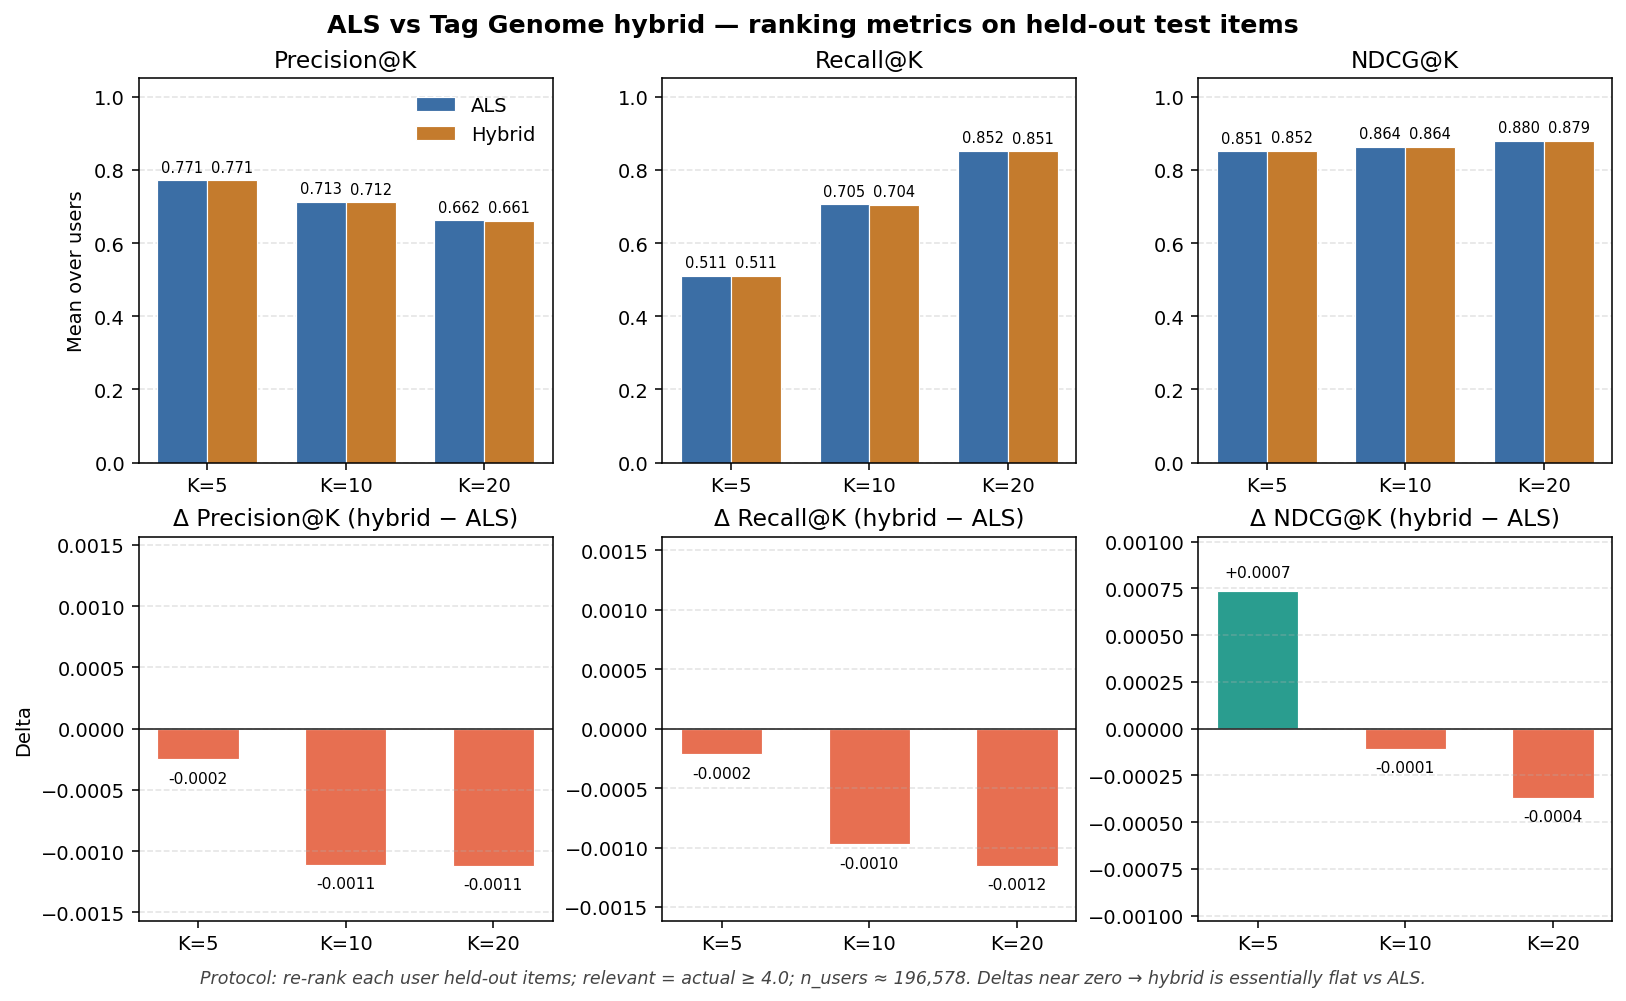

In [1]:
# Ranking comparison plot (ALS vs hybrid) from ranking_metrics.json / prior cell
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import json

# Prefer in-memory payload from the ranking cell; fall back to saved JSON.
_rank_path = RESULTS / "ranking_metrics.json"
if "payload" in dir() and isinstance(payload, dict) and payload.get("by_k"):
    rank_payload = payload
elif _rank_path.exists():
    rank_payload = json.loads(_rank_path.read_text(encoding="utf-8"))
else:
    raise FileNotFoundError(
        f"Missing ranking metrics. Run the ranking cell above first, or ensure {_rank_path}."
    )

ks = [int(k) for k in rank_payload["by_k"].keys()]
metrics = [
    ("precision", "Precision@K"),
    ("recall", "Recall@K"),
    ("ndcg", "NDCG@K"),
]

als_vals = {name: [] for name, _ in metrics}
hyb_vals = {name: [] for name, _ in metrics}
deltas = {name: [] for name, _ in metrics}

for k in ks:
    block = rank_payload["by_k"][str(k)]
    for name, _ in metrics:
        key = f"{name}@{k}"
        als_vals[name].append(float(block["als"][key]))
        hyb_vals[name].append(float(block["hybrid"][key]))
        deltas[name].append(float(block["delta_hybrid_minus_als"][key]))

x = np.arange(len(ks))
width = 0.36
colors = {"als": "#3b6ea5", "hybrid": "#c47b2d"}

fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.8), constrained_layout=True)
fig.suptitle(
    "ALS vs Tag Genome hybrid — ranking metrics on held-out test items",
    fontsize=13,
    fontweight="bold",
)

# Top row: absolute metrics (grouped bars)
for col, (name, title) in enumerate(metrics):
    ax = axes[0, col]
    bars_a = ax.bar(
        x - width / 2,
        als_vals[name],
        width,
        label="ALS",
        color=colors["als"],
        edgecolor="white",
        linewidth=0.6,
    )
    bars_h = ax.bar(
        x + width / 2,
        hyb_vals[name],
        width,
        label="Hybrid",
        color=colors["hybrid"],
        edgecolor="white",
        linewidth=0.6,
    )
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([f"K={k}" for k in ks])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Mean over users" if col == 0 else "")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    if col == 0:
        ax.legend(frameon=False, loc="upper right")

    # Value labels (compact)
    for bars in (bars_a, bars_h):
        for b in bars:
            h = b.get_height()
            ax.text(
                b.get_x() + b.get_width() / 2,
                h + 0.015,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=7.5,
                rotation=0,
            )

# Bottom row: hybrid − ALS deltas (should look near zero → "flat")
for col, (name, title) in enumerate(metrics):
    ax = axes[1, col]
    d = np.asarray(deltas[name], dtype=float)
    bar_colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in d]
    ax.bar(x, d, width=0.55, color=bar_colors, edgecolor="white", linewidth=0.6)
    ax.axhline(0.0, color="#333333", linewidth=0.9)
    ax.set_title(f"Δ {title} (hybrid − ALS)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"K={k}" for k in ks])
    ax.set_ylabel("Delta" if col == 0 else "")
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)
    # Symmetric y so tiny deltas are visible in context
    m = max(1e-4, float(np.max(np.abs(d))) * 1.4)
    ax.set_ylim(-m, m)
    for xi, v in zip(x, d):
        ax.text(
            xi,
            v + (0.06 * m if v >= 0 else -0.06 * m),
            f"{v:+.4f}",
            ha="center",
            va="bottom" if v >= 0 else "top",
            fontsize=8,
        )

n_users = next(iter(rank_payload["by_k"].values()))["als"].get("n_users")
fig.text(
    0.5,
    -0.01,
    (
        f"Protocol: re-rank each user's held-out items; relevant = actual ≥ 4.0"
        + (f"; n_users ≈ {n_users:,}" if n_users else "")
        + ". Deltas near zero → hybrid is essentially flat vs ALS."
    ),
    ha="center",
    va="top",
    fontsize=9,
    style="italic",
    color="#444444",
)

plt.show()


Hybrid is essentially **flat** vs pure ALS on this protocol—deltas are on the order of 0.001 or less. The 0.7/0.3 blend is a content nudge, not a proven ranking upgrade.

### Example: ALS vs hybrid for one user

The next cell picks a random user who has several held-out movies and shows **actual rating**, **ALS prediction**, and **hybrid score** side by side. This is a qualitative check (how scores and ranks move when genome is used), not proof that hybrid is better overall.


In [18]:
# Side-by-side: one random user — actual, ALS, hybrid (from saved hybrid_predictions)
from IPython.display import display

HYBRID_PARQUET = RESULTS / "hybrid_predictions.parquet"
if not HYBRID_PARQUET.exists():
    raise FileNotFoundError(
        f"Missing {HYBRID_PARQUET}. Run the hybrid stage (RUN_GENOME=True) once first."
    )

hpred = pd.read_parquet(HYBRID_PARQUET)
need = {"userId", "movieId", "actual", "prediction", "hybrid_score"}
missing = need - set(hpred.columns)
if missing:
    raise ValueError(f"hybrid predictions missing columns: {sorted(missing)}")

# Prefer users with enough test rows and at least one genome-scored row
MIN_ROWS = 8
rng = np.random.default_rng(50)

counts = hpred.groupby("userId").size()
if "used_genome" in hpred.columns:
    genome_users = set(
        hpred.loc[hpred["used_genome"].fillna(False), "userId"].unique()
    )
    candidates = counts[counts >= MIN_ROWS].index.intersection(genome_users)
else:
    candidates = counts[counts >= MIN_ROWS].index

if len(candidates) == 0:
    candidates = counts[counts >= 3].index
if len(candidates) == 0:
    raise RuntimeError("No users with enough held-out rows to display.")

uid = int(rng.choice(np.asarray(candidates)))
u = hpred.loc[hpred["userId"] == uid].copy()

# Rank both ways for a quick view of order changes
u["als_rank"] = u["prediction"].rank(ascending=False, method="first").astype(int)
u["hybrid_rank"] = u["hybrid_score"].rank(ascending=False, method="first").astype(int)

cols = [
    c
    for c in (
        "movieId",
        "title",
        "actual",
        "prediction",
        "als_scaled",
        "genome_sim",
        "hybrid_score",
        "used_genome",
        "als_rank",
        "hybrid_rank",
    )
    if c in u.columns
]
u_view = u[cols].sort_values("actual", ascending=False).reset_index(drop=True)

print(f"Random userId={uid}  held-out movies={len(u_view)}")
if "used_genome" in u_view.columns:
    print(f"  rows with genome in blend: {int(u_view['used_genome'].fillna(False).sum())} / {len(u_view)}")
print("  Sorted by actual rating (high → low). ALS pred is stars; hybrid_score is a ranking blend in ~[0,1].")
display(u_view.head(15).style.format(
    {
        "actual": "{:.1f}",
        "prediction": "{:.3f}",
        **({"als_scaled": "{:.3f}"} if "als_scaled" in u_view.columns else {}),
        **({"genome_sim": "{:.3f}"} if "genome_sim" in u_view.columns else {}),
        "hybrid_score": "{:.3f}",
    },
    na_rep="—",
))

# Compact correlation: does hybrid reorder likes?
if len(u_view) >= 3:
    spe_als = u_view["actual"].corr(u_view["prediction"], method="spearman")
    spe_hyb = u_view["actual"].corr(u_view["hybrid_score"], method="spearman")
    print(f"  Spearman(actual, ALS pred)    = {spe_als:.3f}")
    print(f"  Spearman(actual, hybrid_score)= {spe_hyb:.3f}")
    print("  (Single user — do not over-read; aggregate metrics are in the ranking section.)")


Random userId=156919  held-out movies=96
  rows with genome in blend: 89 / 96
  Sorted by actual rating (high → low). ALS pred is stars; hybrid_score is a ranking blend in ~[0,1].


,movieId,title,actual,prediction,als_scaled,genome_sim,hybrid_score,used_genome,als_rank,hybrid_rank
0,4886,"Monsters, Inc. (2001)",5.0,4.714,0.936,0.893,0.923,True,4,4
1,56607,"Kite Runner, The (2007)",5.0,4.158,0.813,0.846,0.823,True,48,42
2,30749,Hotel Rwanda (2004),5.0,4.433,0.874,0.806,0.853,True,23,28
3,2090,"Rescuers, The (1977)",5.0,4.256,0.835,0.818,0.830,True,43,39
4,40629,Pride & Prejudice (2005),5.0,4.905,0.979,0.830,0.934,True,1,2
5,1022,Cinderella (1950),5.0,4.584,0.908,0.809,0.878,True,7,15
6,1721,Titanic (1997),5.0,4.266,0.837,0.849,0.841,True,40,35
7,1097,E.T. the Extra-Terrestrial (1982),5.0,4.294,0.843,0.852,0.846,True,35,32
8,33669,"Sisterhood of the Traveling Pants, The (2005)",5.0,4.013,0.781,0.737,0.768,True,64,75
9,80551,Eat Pray Love (2010),5.0,3.745,0.721,0.790,0.742,True,84,84


  Spearman(actual, ALS pred)    = 0.405
  Spearman(actual, hybrid_score)= 0.395
  (Single user — do not over-read; aggregate metrics are in the ranking section.)


## 5. Conclusion

### Full-data ALS

A primary goal of this project was to run a recommender on the **full MovieLens 32M ratings dataset** using Spark in local mode without heavily filtering the data. That goal was met. The final ALS model achieved a **test RMSE of 0.7880** across **6,397,099 scorable held-out ratings**.

In earlier coursework using sampled MovieLens data, Spark ALS produced an RMSE of **1.2301** in approximately **7 seconds**, while Surprise SVD produced an RMSE of **0.8863** in only a few seconds. Spark initially appeared weaker, but those experiments did not take advantage of its primary strength: processing much larger datasets.

Using the complete dataset, ALS learned low-rank user and movie factors from the sparse ratings matrix with the tuned parameters `rank=10`, `maxIter=10`, and `regParam=0.05`. Careful caching, disk spill, and memory cleanup allowed the full model to run successfully on a mid-range local computer.

The sampled and full-data RMSE values are not directly comparable because they were produced using different datasets and evaluation conditions. They are included mainly to show how working with the complete dataset changed my understanding of where Spark becomes useful.

### Hyperparameter selection

The final ALS settings were selected through a small hyperparameter search performed outside this notebook. The search used a deterministic sample containing approximately **10% of users**, including all ratings belonging to those users. This produced approximately **2.54 million ratings from 20,000 users**.

Six combinations of rank, regularization, and iteration count were compared on the sample. The best configuration was then fitted once using the full training dataset. Running a multi-model grid directly on all 32 million ratings would have been unnecessarily expensive on this machine.

#### Model history

| Setup | rank | maxIter | regParam | Test RMSE | Notes |
|---|---:|---:|---:|---:|---|
| Earlier coursework — Surprise SVD | — | — | — | **0.8863** | Sampled data; single-machine |
| Earlier coursework — Spark ALS | — | — | — | **1.2301** | Same sample; not comparable with full 32M |
| Early full-data ALS run | 10 | 5 | 0.10 | **0.8092** | First stable full run |
| Fixed larger ALS model | 20 | 10 | 0.10 | **0.7998** | No grid search |
| **Sample grid → full-data refit** | **10** | **10** | **0.05** | **0.7880** | Final model |

#### Sample-grid validation results

| rank | regParam | maxIter | Validation RMSE |
|---:|---:|---:|---:|
| **10** | **0.05** | **10** | **0.8129** |
| 20 | 0.05 | 10 | 0.8133 |
| 20 | 0.10 | 10 | 0.8157 |
| 10 | 0.10 | 10 | 0.8163 |
| 10 | 0.15 | 10 | 0.8373 |
| 20 | 0.15 | 10 | 0.8422 |

The winning configuration—`rank=10`, `regParam=0.05`, and `maxIter=10`—was used for the full-data model. The sample validation results are provided only as tuning context; the final reported model quality comes from the full-data test evaluation.

### Hybrid ranking

The Tag Genome hybrid successfully added a content-based layer to the ALS predictions. Genome scores were available for approximately **89% of the prediction rows**, demonstrating that the additional dataset could be integrated at a large scale.

However, the fixed **0.7 ALS / 0.3 content** blend produced only negligible changes in Precision, Recall, and NDCG compared with standalone ALS. The content layer therefore did not provide a clear ranking-quality improvement in this experiment.

This is still a useful result. Adding another data source increased model complexity and runtime, but additional information did not automatically produce better recommendations. The hybrid may be more valuable for cold-start users, sparse users, or long-tail movies than for the already well-covered test population used here.

### Runtime and memory management

The project was run on a Windows computer with approximately **31 GB of RAM**. Spark used `local[4]` with a **6 GB driver heap** and eight shuffle partitions.

Typical successful run characteristics were:

| Metric | Value |
|---|---:|
| ALS test RMSE | **0.7880** |
| Test predictions | **6,397,099** |
| Rows using Tag Genome | **5,710,656** (~89%) |
| Valid genome user profiles | **199,157** |
| Genome matrix | **9,734 movies × 1,084 tags** |
| Full ALS runtime | Approximately a few minutes |
| Hybrid runtime | Approximately **9 minutes** |

Running ALS on approximately 32 million ratings was memory-sensitive. An earlier version used memory-only caching, retained unnecessary parent DataFrames, and did not explicitly control Spark memory allocation. Under full-data load, the system became unresponsive and restarted before producing complete outputs.

The successful version used the following memory policy:

| Practice | Purpose |
|---|---|
| Driver heap **6g**, `local[4]`, shuffle partitions **8** | Limit JVM size and local parallelism |
| `spark.memory.fraction=0.5` and `storageFraction=0.2` | Leave additional memory headroom and reduce pressure from cached data |
| `spark.driver.maxResultSize=1g` | Prevent excessively large driver collections |
| `persist(MEMORY_AND_DISK)` | Allow cached partitions to spill to disk |
| Materialize cached stages with actions such as `count()` | Ensure a replacement DataFrame exists before releasing its parent |
| `unpersist()` after major stages | Avoid retaining ratings, splits, and predictions simultaneously |
| Spark Parquet reads and writes | Keep large datasets distributed |
| `toPandas()` only for small samples | Avoid collecting millions of rows into Python memory |
| Windows Hadoop utilities | Support local Spark and Parquet file operations |

The main difficulty was therefore not defining ALS itself, but building a pipeline that could train and evaluate the model without exhausting local memory.

### Next steps

A useful next experiment would be to construct a **cost-quality curve** using stratified samples of the full ratings dataset. Each sample would retain enough ratings per user and movie for ALS to learn meaningful factor vectors. The resulting models could then be compared using:

- Runtime
- Memory use
- RMSE
- Precision, Recall, and NDCG
- Prediction coverage

A sampled ALS model can still score additional combinations involving users and movies represented during training because each prediction is calculated from the dot product of a learned user factor and movie factor. However, the sampled model would learn different factors from the full-data model. Comparisons should therefore use the same commonly scorable test rows or report prediction coverage alongside accuracy.

Another question is whether production recommender systems construct a complete user-by-item prediction matrix. In this project, scoring approximately **6.4 million held-out pairs** was already demanding. Creating every possible combination with `users.crossJoin(movies)` would produce an enormous dense dataset containing mostly predictions that would never be shown to users.

Practical recommender systems generally avoid storing this complete matrix. Instead, they generate a smaller set of candidate items for each user, score those candidates, and retain only the highest-ranked recommendations.

Overall, Spark made it possible to train an ALS model on the complete MovieLens 32M dataset using a local machine. The final ALS model performed well, while incorporating the Tag Genome added complexity without producing a meaningful improvement in performance.